---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 1"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 2. Закони Кірхгофа</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Закони Кірхгофа</li>
  <li>Перший закон</li>
  <li>Другий закон</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 2 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Закони Кірхгофа](#kirchhoff-laws)
    * [🔬 Інтерактивно: розрахунок кола за законами Кірхгофа](#kirchhoff-interactive)
    * [Перший закон](#kirchhoff-first)
    * [Другий закон](#kirchhoff-second)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

---

## Закони Кірхгофа <a class="anchor" id="kirchhoff-laws"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Формулювати перший та другий закони Кірхгофа
> - Складати рівняння вузлів та контурів для електричних схем
> - Визначати кількість незалежних рівнянь для заданої схеми
> - Застосовувати закони Кірхгофа для розрахунку струмів та напруг у простих схемах

</div>

### 📖 Основні поняття

| Поняття | Визначення |
|---------|-----------|
| **Вузол** | Точка кола, де сходяться три і більше провідники |
| **Гілка** | Ділянка кола між двома вузлами, що містить послідовно з'єднані елементи |
| **Контур** | Замкнений шлях в електричній схемі |
| **ЕРС (E)** | Електрорушійна сила, В |
| **Напруга (U, V)** | Різниця потенціалів між двома точками, В |
| **Струм (I)** | Спрямований рух заряджених частинок, А |



Схема, для якої нижче інтерактивно розраховуються струми за законами Кірхгофа: два вузли ($a$, $b$), три гілки і два незалежні контури.

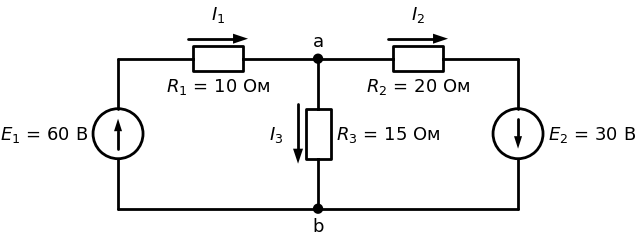

In [2]:
# Schemdraw: схема для законів Кірхгофа — два незалежні контури, три гілки, два вузли
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:
        E1 = d.add(EMF().up().label('$E_1$ = 60 В'))
        R1 = d.add(elm.Resistor().right(4).label('$R_1$ = 10 Ом', loc='bottom'))
        d.add(elm.CurrentLabel(top=True, length=1.2).at(R1).label('$I_1$'))
        A = d.add(elm.Dot().label('a', loc='top'))
        R2 = d.add(elm.Resistor().right(4).label('$R_2$ = 20 Ом', loc='bottom'))
        d.add(elm.CurrentLabel(top=True, length=1.2).at(R2).label('$I_2$'))
        E2 = d.add(EMF().down().label('$E_2$ = 30 В', loc='bottom'))
        d.add(elm.Line().left().tox(A.center))
        B = d.add(elm.Dot().label('b', loc='bottom'))
        d.add(elm.Line().left().tox(E1.start))
        R3 = d.add(elm.Resistor().at(A.center).down().label('$R_3$ = 15 Ом', loc='bottom'))
        d.add(elm.CurrentLabel(top=False, length=1.2).at(R3).label('$I_3$'))
else:
    print('Встановіть schemdraw: pip install schemdraw')

---
### 🔬 Інтерактивно: розрахунок кола за законами Кірхгофа <a class="anchor" id="kirchhoff-interactive"></a>

<div style="background-color: #f5f3ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #7c3aed; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Змінюйте ЕРС джерел та опори резисторів і спостерігайте, як змінюються струми гілок. Зверніть увагу: струм може стати **від'ємним** — це означає лише, що його дійсний напрямок протилежний обраному умовно-додатному.

</div>

In [3]:
# Інтерактивний розрахунок: два контури за законами Кірхгофа
def kirchhoff_interactive(E1=60, E2=30, R1=10, R2=20, R3=15):
    I1s, I2s, I3s = smp.symbols('I1 I2 I3')
    eq1 = I1s*R1 + I3s*R3 - E1
    eq2 = I2s*R2 - I3s*R3 - E2
    eq3 = I1s - I2s - I3s
    sol = smp.solve([eq1, eq2, eq3], [I1s, I2s, I3s])
    i1, i2, i3 = float(sol[I1s]), float(sol[I2s]), float(sol[I3s])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    colors = ['#2196F3' if v >= 0 else '#F44336' for v in [i1, i2, i3]]
    bars = ax1.bar(['I1', 'I2', 'I3'], [i1, i2, i3], color=colors, edgecolor='k')
    for bar, val in zip(bars, [i1, i2, i3]):
        ax1.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height() + 0.03*max(abs(i1),abs(i2),abs(i3)),
                 f'{val:.3f} A', ha='center', va='bottom', fontsize=10)
    ax1.set_title('Струми в гілках (А)')
    ax1.set_ylabel('Струм, А')
    ax1.axhline(0, color='k', linewidth=0.8)

    P1, P2, P3 = i1**2*R1, i2**2*R2, i3**2*R3
    ax2.bar(['P1=I1²R1', 'P2=I2²R2', 'P3=I3²R3'], [P1, P2, P3],
            color=['#4CAF50','#FF9800','#9C27B0'], edgecolor='k')
    ax2.set_title('Потужність розсіювання (Вт)')
    ax2.set_ylabel('Потужність, Вт')

    kcl_ok = abs(i1 - i2 - i3) < 1e-9
    plt.suptitle(f'KCL: I1=I2+I3 -> {i1:.3f}={i2:.3f}+{i3:.3f} OK' if kcl_ok else 'KCL не виконано!',
                 fontsize=11, color='green' if kcl_ok else 'red')
    plt.tight_layout(); plt.show()
    print(f'I1={i1:.4f} A | I2={i2:.4f} A | I3={i3:.4f} A')
    print(f'P_rozs = {P1+P2+P3:.2f} Вт | P_dzherel = {E1*i1+E2*i2:.2f} Вт')

interact(kirchhoff_interactive,
         E1=widgets.FloatSlider(min=10, max=120, step=5, value=60, description='E1 (В)'),
         E2=widgets.FloatSlider(min=0, max=60, step=5, value=30, description='E2 (В)'),
         R1=widgets.FloatSlider(min=1, max=100, step=1, value=10, description='R1 (Ом)'),
         R2=widgets.FloatSlider(min=1, max=100, step=1, value=20, description='R2 (Ом)'),
         R3=widgets.FloatSlider(min=1, max=100, step=1, value=15, description='R3 (Ом)'))

interactive(children=(FloatSlider(value=60.0, description='E1 (В)', max=120.0, min=10.0, step=5.0), FloatSlide…

<function __main__.kirchhoff_interactive(E1=60, E2=30, R1=10, R2=20, R3=15)>

---
### Перший закон <a class="anchor" id="kirchhoff-first"></a>

> Алгебраїчна сума струмів, які сходяться у вузлі електричного кола рівна нулю

### Другий закон <a class="anchor" id="kirchhoff-second"></a>

> Алгебраїчна сума ЕРС в замкненому контурі рівна алгебраїчній сумі падінь напруг на всіх опорах цього контуру


Розглянемо вузол, у якому сходяться чотири гілки. Струми $I_1$ та $I_4$ втікають у вузол, $I_2$ та $I_3$ — витікають:

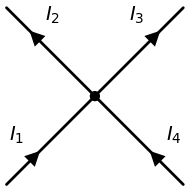

In [4]:
# Схема: вузол електричного кола з чотирма гілками
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=14, unit=2.5) as d:
        for ang, name, into in [(225, 'I_1', True), (135, 'I_2', False), (45, 'I_3', False), (315, 'I_4', True)]:
            w = d.add(elm.Line().at((0, 0)).theta(ang))
            d.add(elm.CurrentLabelInline(direction='out' if into else 'in', ofst=-0.6).at(w).label(f'${name}$'))
        d.add(elm.Dot().at((0, 0)))

Запишемо рівняння вузла у відповідності до першого закону:

$I_1 - I_2 - I_3 + I_4 = 0$

Перенесено струми,які виходять з вузла в праву частину:

$I_1 + I_4 = I_2 + I_3$

Розглянемо контур з джерелом ЕРС $E$ і резисторами $R_1$, $R_2$. Обходимо контур за годинниковою стрілкою:

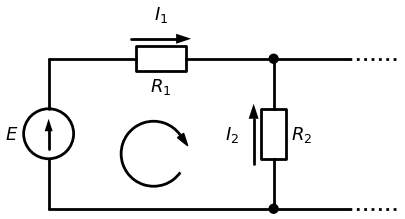

In [5]:
# Схема: контур для другого закону Кірхгофа (напрямок обходу — за годинниковою стрілкою)
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:
        E = d.add(EMF().up().label('$E$'))
        R1 = d.add(elm.Resistor().right(4.5).label('$R_1$', loc='bottom'))
        d.add(elm.CurrentLabel(top=True, length=1.2).at(R1).label('$I_1$'))
        a = d.add(elm.Dot())
        d.add(elm.Line().right(1.5))
        d.add(elm.Line().right(1).linestyle(':'))
        R2 = d.add(elm.Resistor().at(a.center).down().label('$R_2$', loc='bottom'))
        d.add(elm.CurrentLabel(top=False, length=1.2, reverse=True).at(R2).label('$I_2$'))
        b = d.add(elm.Dot())
        d.add(elm.Line().right(1.5))
        d.add(elm.Line().right(1).linestyle(':'))
        d.add(elm.Line().at(b.center).left().tox(E.start))
        d.add(elm.LoopArrow(direction='cw', width=1.3, height=1.3).at((2.1, 1.1)))

Запишемо рівняння у відповідності до другого закону
 
 $$ I_1 \cdot R_1 - I_2 \cdot R_2 = E $$

---

### 📌 Підсумок: Закони Кірхгофа

<div style="background-color: #f0fdf4; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Перший закон (закон вузлів — KCL):**
$$\sum_{k=1}^{n} I_k = 0$$
Алгебраїчна сума струмів у вузлі дорівнює нулю. Струми, що входять у вузол — додатні, що виходять — від'ємні.

**Другий закон (закон контурів — KVL):**
$$\sum_{k=1}^{m} E_k = \sum_{k=1}^{m} I_k R_k$$
Алгебраїчна сума ЕРС у замкненому контурі дорівнює алгебраїчній сумі падінь напруг.

</div>

**Кількість незалежних рівнянь:**
- За KCL: $n - 1$ рівнянь (де $n$ — кількість вузлів)
- За KVL: $m - n + 1$ рівнянь (де $m$ — кількість гілок)
- Загальна кількість рівнянь = кількість гілок = кількість невідомих

---


---
### ⚡ Практичне застосування: Закони Кірхгофа в радіотехніці

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Де використовуються закони Кірхгофа в реальних пристроях:**

| Пристрій | Застосування KCL/KVL |
|----------|---------------------|
| **Підсилювач на BJT** | KCL у вузлі бази: $I_B + I_C = I_E$; KVL для визначення робочої точки |
| **Блок живлення** | KVL для розрахунку спадів напруги на регулюючому елементі |
| **Антенний подільник** | KCL для розподілу потужності між антенами |
| **Міст Вітстона** | KVL для умов балансу: $R_1/R_2 = R_3/R_4$ |
| **Диференційний підсилювач** | KCL для розрахунку вхідних/вихідних струмів |

> **Приклад:** У підсилювачі на BJT зі спільним емітером KVL по вхідному контуру:
> $V_{CC} = I_B R_B + V_{BE}$, і KCL у вузлі колектора: $I_C = \beta I_B$.

</div>

---
### ✅ Питання для самоперевірки: Закони Кірхгофа

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому кількість незалежних рівнянь KCL дорівнює $n-1$?</summary>

> **Відповідь:** Сума всіх $n$ KCL-рівнянь тотожно дорівнює нулю — кожен струм входить до двох вузлів зі знаками, що взаємно компенсуються. Тому одне рівняння завжди є лінійно залежним.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Схема: 5 вузлів, 8 гілок. Скільки незалежних рівнянь KCL і KVL?</summary>

> **Відповідь:** KCL: $n-1 = 4$; KVL: $m - n + 1 = 8 - 5 + 1 = 4$. Разом 8 рівнянь = 8 невідомих струмів.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чи виконуються закони Кірхгофа для кіл змінного струму?</summary>

> **Відповідь:** Так, у комплексній формі. KCL: $\sum \dot{I}_k = 0$; KVL: $\sum \dot{E}_k = \sum \dot{I}_k Z_k$, де $\dot{I}_k$ — комплексні амплітуди струмів, $Z_k$ — комплексні імпеданси.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4 (поглиблений рівень).</b> Який фізичний зміст KCL з погляду електродинаміки?</summary>

> **Відповідь:** KCL — наслідок закону збереження заряду. У квазістаціонарному наближенні $\nabla \cdot \mathbf{J} = 0$, що при інтегруванні по замкненій поверхні навколо вузла дає $\sum I_k = 0$.

</details>

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Плутанина знаків при обході контуру (KVL).** Оберіть один напрямок обходу (наприклад, за годинниковою стрілкою) і дотримуйтесь простого правила: якщо напрямок струму через елемент **співпадає** з напрямком обходу — падіння напруги береться зі знаком «+»; якщо ЕРС джерела спрямована **проти** напрямку обходу — вона береться зі знаком «−». Напрямок обходу можна обирати довільно — результат від цього не зміниться, головне не змінювати правило знаків посеред одного й того ж рівняння.


</div>


### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Густав Кірхгоф сформулював свої закони у **1845 році**, ще будучи 21-річним студентом Кенігсберзького університету — задовго до появи радіо. Він застосовував їх для аналізу **телеграфних ліній**, попередниць сучасних ліній передачі (див. розділ «Довга лінія» у Частині 2). З погляду електродинаміки закони Кірхгофа — окремий випадок рівнянь Максвелла у квазістаціонарному наближенні, коли розміри кола набагато менші за довжину хвилі сигналу.


</div>


---
### 📝 Задачі для самостійного розв'язання: Закони Кірхгофа


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Два джерела $E_1 = 10$ В ($R_1 = 2$ Ом) і $E_2 = 5$ В ($R_2 = 1$ Ом) працюють паралельно на спільне навантаження $R_3 = 4$ Ом (усі три гілки з'єднують ті самі два вузли, ЕРС напрямлені до верхнього вузла). Складіть рівняння за законами Кірхгофа та знайдіть струми.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $I_1 + I_2 = I_3$; $\;I_1R_1 + I_3R_3 = E_1$; $\;I_2R_2 + I_3R_3 = E_2$.
> Розв'язок: $I_1 \approx 2{,}143$ А, $I_2 \approx -0{,}714$ А, $I_3 \approx 1{,}429$ А. Від'ємний $I_2$ означає, що друге джерело **споживає** енергію (заряджається від першого).

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Схема має $n = 4$ вузли та $m = 6$ гілок без джерел струму. Скільки рівнянь потрібно скласти за першим і за другим законами Кірхгофа?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> За першим законом: $n - 1 = 3$; за другим: $m - n + 1 = 3$. Разом $6$ рівнянь — по одному на кожен невідомий струм гілки.

</details>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 1. Елементи електричного кола. Перетворення кіл, послідовне та паралельне з'єднання](Тема_01_Елементи_та_перетворення_електричних_кіл.ipynb) &nbsp;|&nbsp; [Тема 3. Метод вузлових потенціалів](Тема_03_Метод_вузлових_потенціалів.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
